# WRAPIFY.ipynb
### Wrapify will take your Spotify data and give you many of the same metrics that you can expect to receive from a typical Spotify Wrapped, including:
- Top 20 songs of all time
- Top 10 songs for each year
- Top 20 artists of all time
- Top 10 artists of each year
- Top 10 albums of all time
- Top 5 albums of each year
- Total minutes, hours, and days listened for all time 
- Total minutes, hours, and days listened each year

#### Each individual metric has an associated table and bar plot so you can visualize your spotify data

### This is a passion project that I am still actively working on, but all basic functions have been completed! The following functionality will hopefully be added in the future:

#### Choose between count or ms
be prompted at the beginning of the program about your listeninf preference
- choosing by MS means your top results are determined by the amount of time you spent listening to them
- choosing by count means your top results are determined by the number of times a value appears in your data

#### search for a specific song for the following results:
- how many listens you had all time
- How many listens did you have each year, with a visual graph
- How many times have you skipped each year + graph
- How many times have you skipped all time

#### search for a specific artist for the following results:
- how many listens you had all time
- How many listens did you have each year, with a visual graph
- How many individual songs have you listened to by them
- a graph showing which songs got replayed the most
- How many times have you skipped each year + graph
- How many times have you skipped all time

#### What genre is most popular with the user?
- include visuals to show which genres are most listened to
- if possible, list a song's genre alongside its artist and album
- if possible, list an artist's genre

In [1]:
import os
import pandas as pd
import seaborn as sns

# for data visualizations
sns.set_theme()
sns.set_palette("deep")

folder = 'Spotify Extended Streaming History/Streaming History'  # folder containing JSON files
#---------------------------------------------------------------------------------
# The following code is meant to load a series of JSON files from one folder, 
# concatenate them all together, remove rows with null values, and save them as 
# an entirely new csv file that can then be used for data queries.
#---------------------------------------------------------------------------------
def merge_json_files(folder):
    merged_data = pd.DataFrame()

    # ensure folder exists
    if not os.path.isdir(folder):
        print(f"Error: Folder '{folder}' not found.")
        return

    # iterate through all files in the folder
    for filename in os.listdir(folder):
        if filename.endswith('.json'): # ensure it ends in .json
            filepath = os.path.join(folder, filename)
            try:
                with open(filepath, encoding='utf-8') as f:
                    data = pd.read_json(f)
                    merged_data = pd.concat([merged_data, data], ignore_index=True) 
            except ValueError as e:
                print(f"Warning: failed to read {filename}: {e}") # exception, failure to read json files
        if merged_data.empty:
            print(f"No JSON rows found in '{folder}'.") # catch to say there are no rows
            return      
        
        # remove any rows without a track name
        cleaned_data = merged_data.dropna(subset=['master_metadata_track_name'])

        # I don't want any of these keys in the final dataset
        keys_to_remove = [
            "platform", "conn_country", "ip_addr", "episode_name", "episode_show_name", 
            "spotify_episode_uri","audiobook_title", "audiobook_uri", "audiobook_chapter_uri", 
            "audiobook_chapter_title", "incognito_mode", "offline_timestamp"
            ]
        for key in keys_to_remove:
            cleaned_data.pop(key)

        # renaming columns for better readability
        cleaned_data = cleaned_data.rename(columns={ 
            'master_metadata_track_name': 'song_title',
            'master_metadata_album_artist_name': 'artist_name',
            'master_metadata_album_album_name': 'album_name',
            'spotify_track_uri': 'track_url'
        })

        # Keeps rows where ms_played is between 20000 and 900000
        # songs outside of this range are removed
        cleaned_data = cleaned_data[cleaned_data['ms_played'].between(20000, 900000)]

        # replace '$' with 'S' since it gets misread by the parser
        cleaned_data['song_title'] = cleaned_data['song_title'].astype(str).str.replace('$', 'S', regex=False)
        cleaned_data['album_name'] = cleaned_data['album_name'].astype(str).str.replace('$', 'S', regex=False)
        cleaned_data['artist_name'] = cleaned_data['artist_name'].astype(str).str.replace('$', 'S', regex=False)

    # remove null values and save merged DataFrame to JSON file (pretty formatted)
    cleaned_data.to_csv('streaming_history.csv', index=False)
    print(f"Merged {len(cleaned_data)} total rows from {folder}/")

# run the function
merge_json_files(folder)

Error: Folder 'Spotify Extended Streaming History/Streaming History' not found.


# Top 20 tracks and artists

In [2]:
#---------------------------------------------------------------------------------
# The following code will produce the most listened to songs, artists, and albums of all time
#---------------------------------------------------------------------------------
with open('streaming_history.csv', encoding='utf-8') as f:
    data = pd.read_csv(f)

    top_tracks_summary = ( # ensure a song has the same artist and album name before adding it to the count
        data.groupby(['song_title', 'artist_name', 'album_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(20)
    )
            
    top_artists_summary = (
        data.groupby(['artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(20)
    )

    top_albums_summary = ( # ensure an album has the same artist before adding it to the count
        data.groupby(['album_name', 'artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )
    
    # calculate the total minutes, hours, and days played
    total_ms_played = data['ms_played'].sum()
    total_minutes = (total_ms_played / 1000) / 60
    total_minutes = total_minutes.astype(int)
    total_hours = int(total_minutes / 60)
    total_days = int(total_hours / 24)

## Total time listened for all time

In [3]:
print(
    "==================================================================================\n"
    "You've enjoyed music for a total of", total_minutes, "minutes, or", total_hours, "hours, or ", total_days, "days \n"
    "=================================================================================="
)

You've enjoyed music for a total of 200816 minutes, or 3346 hours, or  139 days 


## Top 20 songs

,song_title,album_name,play_count,artist
0,Stand By You,Wildfire,171,Rachel Platten
1,The Sound of Silence,Immortalized,137,Disturbed
2,Chocolate,The 1975,130,The 1975
3,Starlight,Black Holes and Revelations,126,Muse
4,Revolt,Drones,123,Muse
5,The Only Hope for Me Is You,Danger Days: The True Lives of the Fabulous Ki...,114,My Chemical Romance
6,Undertale (Music Box),Undertale (Music Box),114,Jayn
7,United States of Eurasia (+Collateral Damage),The Resistance,113,Muse
8,Monkey Tree - UK Mix,Very Good Bad Thing,112,Mother Mother
9,High School,Darling,110,SayWeCanFly


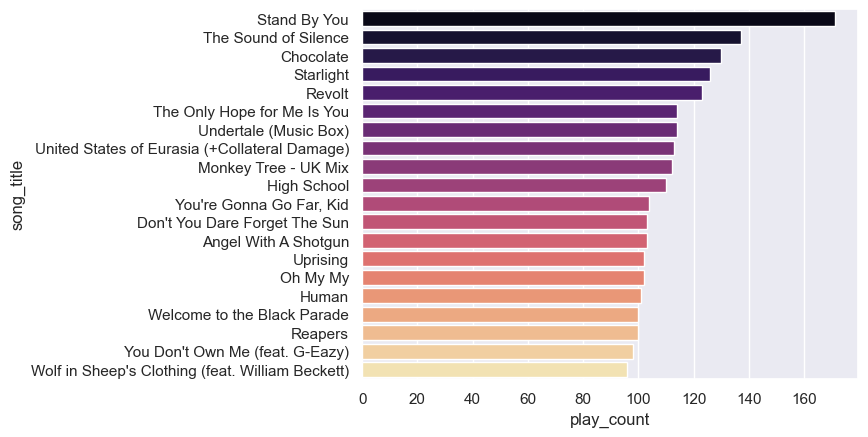

In [4]:
# print a bar plot including the top 20 tracks of all time
sns.barplot(x="play_count", y="song_title", data=top_tracks_summary,
            label="Total", palette="magma", hue="song_title", legend=False)
# print a table including the top 20 tracks of all time
top_tracks_summary_anagram = top_tracks_summary.melt(id_vars=["song_title", "album_name", "play_count"], value_name="artist").drop(columns=["variable"])
top_tracks_summary_anagram.head(20)

## Top 20 artists

,artist_name,play count
0,Muse,2973
1,Twenty One Pilots,2153
2,One Direction,1747
3,Panic! At The Disco,1444
4,My Chemical Romance,1439
5,Imagine Dragons,1414
6,Ghost,1365
7,Bleachers,947
8,Halsey,881
9,Lorde,809


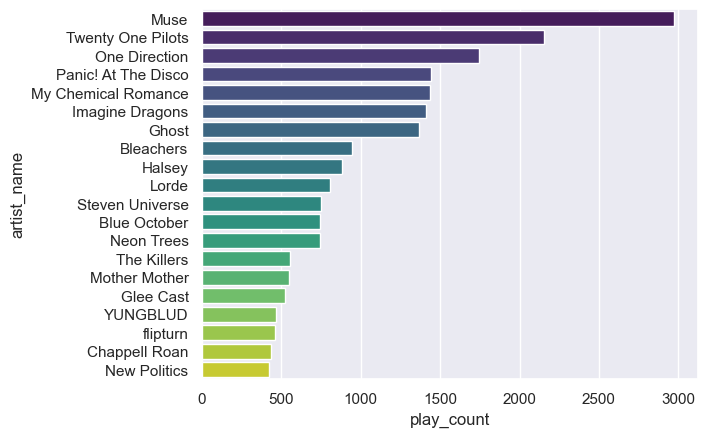

In [5]:
# print a bar plot including the top 20 tracks of all time
sns.barplot(x="play_count", y="artist_name", data=top_artists_summary,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 20 tracks of all time
top_artists_summary_anagram = top_artists_summary.melt(id_vars=["artist_name"], value_name="play count").drop(columns=["variable"])
top_artists_summary_anagram.head(20)

## Top 10 Albums

,album_name,play_count,artist name
0,"Steven Universe, Vol. 1 (Original Soundtrack)",656,Steven Universe
1,Death of a Bachelor,642,Panic! At The Disco
2,Danger Days: The True Lives of the Fabulous Ki...,587,My Chemical Romance
3,Smoke + Mirrors,583,Imagine Dragons
4,Black Holes and Revelations,572,Muse
5,Blurryface,572,Twenty One Pilots
6,The Resistance,552,Muse
7,Twenty One Pilots,536,Twenty One Pilots
8,The Black Parade,531,My Chemical Romance
9,BADLANDS,511,Halsey


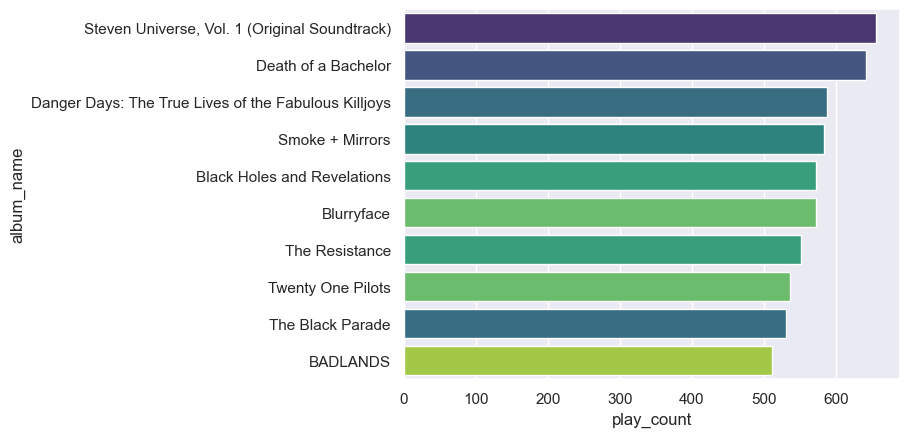

In [6]:
# print a bar plot including the top 10 Albums of all time
sns.barplot(x="play_count", y="album_name", data=top_albums_summary,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 20 tracks of all time
top_albums_summary_anagram = top_albums_summary.melt(id_vars=["album_name", "play_count"], value_name="artist name").drop(columns=["variable"])
top_albums_summary_anagram.head(10)

## Listening trends by year

In [7]:
#---------------------------------------------------------------------------------
# The following code will produce the most listened to songs, artists, and albums of each year
#---------------------------------------------------------------------------------
with open('streaming_history.csv', encoding='utf-8') as f:
    data = pd.read_csv(f)

    # dataset for 2016 listening patterns
    data_2016 = data[data['ts'].between('2016-01-00T00:00:00Z', '2016-12-31T23:59:59Z')]
    top_tracks_2016 = (
        data_2016.groupby(['song_title', 'artist_name', 'album_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_artists_2016 = (
        data_2016.groupby(['artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_albums_2016 = (
        data_2016.groupby(['album_name', 'artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(5)
    )

    ms_played_2016 = data_2016['ms_played'].sum()
    minutes_2016 = (ms_played_2016 / 1000) / 60
    minutes_2016 = minutes_2016.astype(int)
    hours_2016 = int(minutes_2016 / 60)
    days_2016 = int(hours_2016 / 24)

    # dataset for 2017 listening patterns
    data_2017 = data[data['ts'].between('2017-01-00T00:00:00Z', '2017-12-31T23:59:59Z')]
    top_tracks_2017 = (
        data_2017.groupby(['song_title', 'artist_name', 'album_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_artists_2017 = (
        data_2017.groupby(['artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_albums_2017 = (
        data_2017.groupby(['album_name', 'artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(5)
    )

    ms_played_2017 = data_2017['ms_played'].sum()
    minutes_2017 = (ms_played_2017 / 1000) / 60
    minutes_2017 = minutes_2017.astype(int)
    hours_2017 = int(minutes_2017 / 60)
    days_2017 = int(hours_2017 / 24)

    # dataset for 2018 listening patterns
    data_2018 = data[data['ts'].between('2018-01-00T00:00:00Z', '2018-12-31T23:59:59Z')]
    top_tracks_2018 = (
        data_2018.groupby(['song_title', 'artist_name', 'album_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_artists_2018 = (
        data_2018.groupby(['artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_albums_2018 = (
        data_2018.groupby(['album_name', 'artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(5)
    )

    ms_played_2018 = data_2018['ms_played'].sum()
    minutes_2018 = (ms_played_2018 / 1000) / 60
    minutes_2018 = minutes_2018.astype(int)
    hours_2018 = int(minutes_2018 / 60)
    days_2018 = int(hours_2018 / 24)

    # dataset for 2019 listening patterns
    data_2019 = data[data['ts'].between('2019-01-00T00:00:00Z', '2019-12-31T23:59:59Z')]
    top_tracks_2019 = (
        data_2019.groupby(['song_title', 'artist_name', 'album_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_artists_2019 = (
        data_2019.groupby(['artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )
    
    top_albums_2019 = (
        data_2019.groupby(['album_name', 'artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(5)
    )

    ms_played_2019 = data_2019['ms_played'].sum()
    minutes_2019 = (ms_played_2019 / 1000) / 60
    minutes_2019 = minutes_2019.astype(int)
    hours_2019 = int(minutes_2019 / 60)
    days_2019 = int(hours_2019 / 24)

    # dataset for 2020 listening patterns
    data_2020 = data[data['ts'].between('2020-01-00T00:00:00Z', '2020-12-31T23:59:59Z')]
    top_tracks_2020 = (
        data_2020.groupby(['song_title', 'artist_name', 'album_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_artists_2020 = (
        data_2020.groupby(['artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_albums_2020 = (
        data_2020.groupby(['album_name', 'artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(5)
    )

    ms_played_2020 = data_2020['ms_played'].sum()
    minutes_2020 = (ms_played_2020 / 1000) / 60
    minutes_2020 = minutes_2020.astype(int)
    hours_2020 = int(minutes_2020 / 60)
    days_2020 = int(hours_2020 / 24)

    # dataset for 2021 listening patterns
    data_2021 = data[data['ts'].between('2021-01-00T00:00:00Z', '2021-12-31T23:59:59Z')]
    top_tracks_2021 = (
        data_2021.groupby(['song_title', 'artist_name', 'album_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_artists_2021 = (
        data_2021.groupby(['artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_albums_2021 = (
        data_2021.groupby(['album_name', 'artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(5)
    )

    ms_played_2021 = data_2021['ms_played'].sum()
    minutes_2021 = (ms_played_2021 / 1000) / 60
    minutes_2021 = minutes_2021.astype(int)
    hours_2021 = int(minutes_2021 / 60)
    days_2021 = int(hours_2021 / 24)

    # dataset for 2022 listening patterns
    data_2022 = data[data['ts'].between('2022-01-00T00:00:00Z', '2022-12-31T23:59:59Z')]
    top_tracks_2022 = (
        data_2022.groupby(['song_title', 'artist_name', 'album_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_artists_2022 = (
        data_2022.groupby(['artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_albums_2022 = (
        data_2022.groupby(['album_name', 'artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(5)
    )

    ms_played_2022 = data_2022['ms_played'].sum()
    minutes_2022 = (ms_played_2022 / 1000) / 60
    minutes_2022 = minutes_2022.astype(int)
    hours_2022 = int(minutes_2022 / 60)
    days_2022 = int(hours_2022 / 24)

    # dataset for 2023 listening patterns
    data_2023 = data[data['ts'].between('2023-01-00T00:00:00Z', '2023-12-31T23:59:59Z')]
    top_tracks_2023 = (
        data_2023.groupby(['song_title', 'artist_name', 'album_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_artists_2023 = (
        data_2023.groupby(['artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_albums_2023 = (
        data_2023.groupby(['album_name', 'artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(5)
    )

    ms_played_2023 = data_2023['ms_played'].sum()
    minutes_2023 = (ms_played_2023 / 1000) / 60
    minutes_2023 = minutes_2023.astype(int)
    hours_2023 = int(minutes_2023 / 60)
    days_2023 = int(hours_2023 / 24)

    # dataset for 2024 listening patterns
    data_2024 = data[data['ts'].between('2024-01-00T00:00:00Z', '2024-12-31T23:59:59Z')]
    top_tracks_2024 = (
        data_2024.groupby(['song_title', 'artist_name', 'album_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )
    
    top_artists_2024 = (
        data_2024.groupby(['artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_albums_2024 = (
        data_2024.groupby(['album_name', 'artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(5)
    )

    ms_played_2024 = data_2024['ms_played'].sum()
    minutes_2024 = (ms_played_2024 / 1000) / 60
    minutes_2024 = minutes_2024.astype(int)
    hours_2024 = int(minutes_2024 / 60)
    days_2024 = int(hours_2024 / 24)

    # dataset for 2025 listening patterns
    data_2025 = data[data['ts'].between('2025-01-00T00:00:00Z', '2025-12-31T23:59:59Z')]
    top_tracks_2025 = (
        data_2025.groupby(['song_title', 'artist_name', 'album_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_artists_2025 = (
        data_2025.groupby(['artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(10)
    )

    top_albums_2025 = (
        data_2025.groupby(['album_name', 'artist_name'])
            .size()
            .reset_index(name='play_count')
            .sort_values(by='play_count', ascending=False)
            .head(5)
    )

    ms_played_2025 = data_2025['ms_played'].sum()
    minutes_2025 = (ms_played_2025 / 1000) / 60
    minutes_2025 = minutes_2025.astype(int)
    hours_2025 = int(minutes_2025 / 60)
    days_2025 = int(hours_2025 / 24)

## Total Hours Listened by Year

<Axes: xlabel='year', ylabel='hours'>

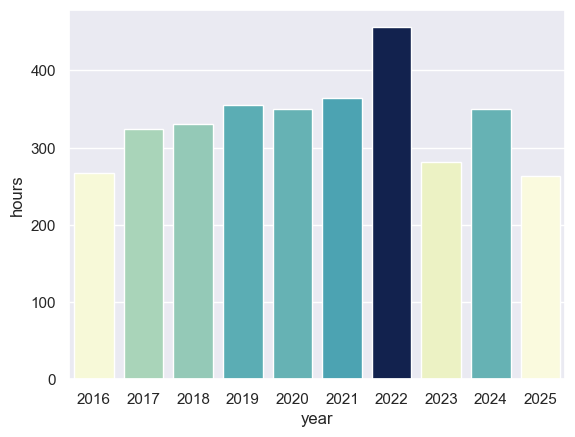

In [8]:
# Bar plot to show hours listened to each year
ms_by_year = {
    'year': ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025'],
    'hours': [hours_2016, hours_2017, hours_2018, hours_2019, hours_2020, hours_2021, hours_2022, hours_2023, hours_2024, hours_2025]
    }
ms_df = pd.DataFrame(ms_by_year)
sns.barplot(x="year", y="hours", data=ms_df,
            label="Total", palette="YlGnBu", hue="hours", legend=False)

## 2016

In [9]:
print(
    "==================================================================================\n"
    "In 2016, you've enjoyed music for a total of", minutes_2016, "minutes, or", hours_2016, "hours, or ", days_2016, "days \n"
    "=================================================================================="
)

In 2016, you've enjoyed music for a total of 16050 minutes, or 267 hours, or  11 days 


### Top 10 Songs

,song_title,album_name,play_count,artist
0,Stand By You,Wildfire,171,Rachel Platten
1,The Sound of Silence,Immortalized,100,Disturbed
2,Angel With A Shotgun,Symphony Soldier,74,The Cab
3,Undertale (Music Box),Undertale (Music Box),64,Jayn
4,Heathens,Heathens,59,Twenty One Pilots
5,CHARIOTS OF FIRE - Café Buddha Del Mar Bar Mix...,Lounge Of Love,56,Eternal-Flame
6,"You're Gonna Go Far, Kid","Rise And Fall, Rage And Grace",53,The Offspring
7,High School,Darling,51,SayWeCanFly
8,Metal Crusher (Undertale) [Piano Version],UNDERTALE (Piano Selections),49,Game Soundtrack Cat
9,Hopes and Dreams ~ SAVE the World,Undertale Symphonic Metal,47,Ferdk


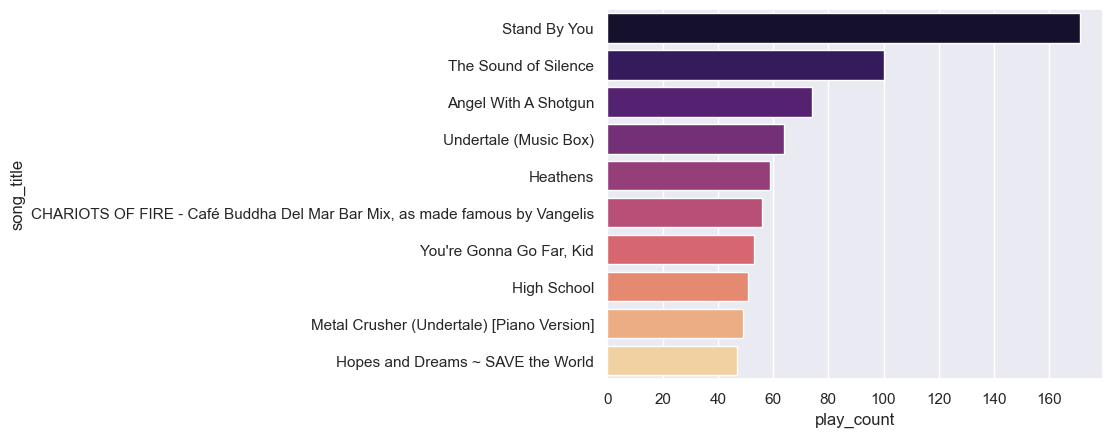

In [10]:
# print a bar plot including the top 10 tracks of 2016
sns.barplot(x="play_count", y="song_title", data=top_tracks_2016,
            label="Total", palette="magma", hue="song_title", legend=False)
# print a table including the top 10 tracks of 2016
top_tracks_2016_anagram = top_tracks_2016.melt(id_vars=["song_title", "album_name", "play_count"], value_name="artist").drop(columns=["variable"])
top_tracks_2016_anagram.head(10)

### Top 10 Artists

,artist_name,play count
0,Twenty One Pilots,892
1,Panic! At The Disco,462
2,Imagine Dragons,284
3,Halsey,216
4,Rachel Platten,171
5,Ferdk,112
6,Disturbed,100
7,Daya,93
8,Holder,85
9,Nate Ruess,76


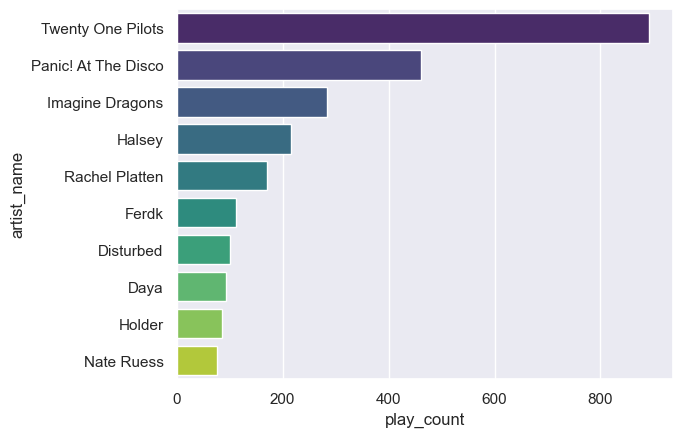

In [11]:
# print a bar plot including the top 10 artists of 2016
sns.barplot(x="play_count", y="artist_name", data=top_artists_2016,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 10 artists of 2016
top_artists_2016_anagram = top_artists_2016.melt(id_vars=["artist_name"], value_name="play count").drop(columns=["variable"])
top_artists_2016_anagram.head(10)

### Top 5 Albums

,album_name,play_count,artist name
0,Death of a Bachelor,296,Panic! At The Disco
1,Blurryface,286,Twenty One Pilots
2,Twenty One Pilots,271,Twenty One Pilots
3,Vessel,233,Twenty One Pilots
4,Smoke + Mirrors,209,Imagine Dragons


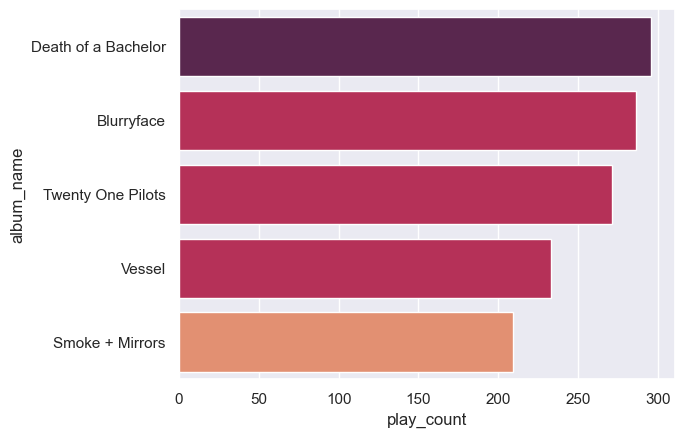

In [12]:
# print a bar plot including the top 5 Albums of 2016
sns.barplot(x="play_count", y="album_name", data=top_albums_2016,
            label="Total", palette="rocket", hue="artist_name", legend=False)
# print a table including the top 5 Albums of 2016
top_albums_2016_anagram = top_albums_2016.melt(id_vars=["album_name", "play_count"], value_name="artist name").drop(columns=["variable"])
top_albums_2016_anagram.head(5)

## 2017

In [13]:
print(
    "==================================================================================\n"
    "In 2017, you've enjoyed music for a total of", minutes_2017, "minutes, or", hours_2017, "hours, or ", days_2017, "days \n"
    "=================================================================================="
)

In 2017, you've enjoyed music for a total of 19455 minutes, or 324 hours, or  13 days 


### Top 10 Songs

,song_title,album_name,play_count,artist
0,I Dreamed A Dream (Glee Cast Version) (feat. I...,"Glee: The Music, Volume 3 Showstoppers",54,Glee Cast
1,You Don't Own Me (feat. G-Eazy),FMA,42,SAYGRACE
2,I'm Ready,Living Room,34,AJR
3,True Love,The Truth About Love,34,P!nk
4,Feeling Good,It's Time,33,Michael Bublé
5,Copacabana (Glee Cast Version),Copacabana (Glee Cast Version),33,Glee Cast
6,Total Eclipse Of The Heart (Glee Cast Version)...,"Glee: The Music, Volume 3 Showstoppers",31,Glee Cast
7,Without Me,The Eminem Show,30,Eminem
8,BOSS,Reflection,30,Fifth Harmony
9,Thunder,Evolve,29,Imagine Dragons


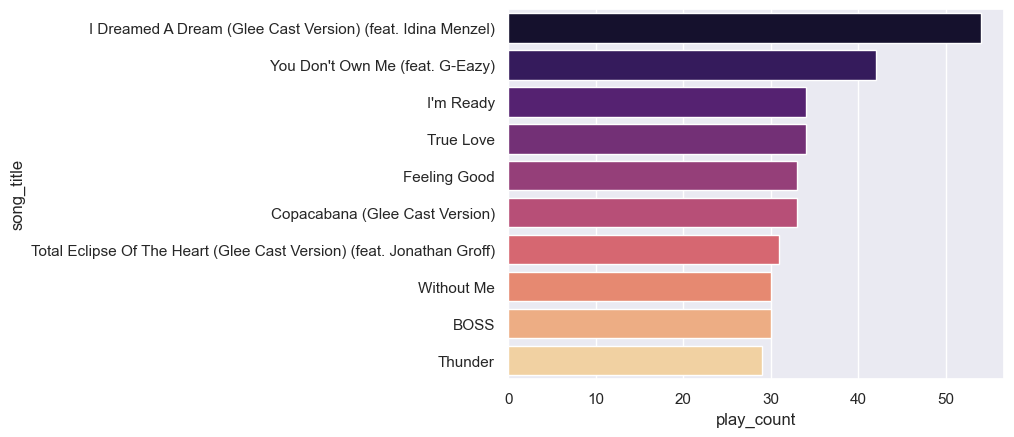

In [14]:
# print a bar plot including the top 10 tracks of 2017
sns.barplot(x="play_count", y="song_title", data=top_tracks_2017,
            label="Total", palette="magma", hue="song_title", legend=False)
# print a table including the top 10 tracks of 2017
top_tracks_2017_anagram = top_tracks_2017.melt(id_vars=["song_title", "album_name", "play_count"], value_name="artist").drop(columns=["variable"])
top_tracks_2017_anagram.head(10)

### Top 10 Artists

,artist_name,play count
0,Imagine Dragons,616
1,Twenty One Pilots,507
2,Steven Universe,406
3,Halsey,335
4,Panic! At The Disco,244
5,Glee Cast,198
6,Leslie Odom Jr.,70
7,Hailee Steinfeld,62
8,Ben Platt,61
9,Ed Sheeran,57


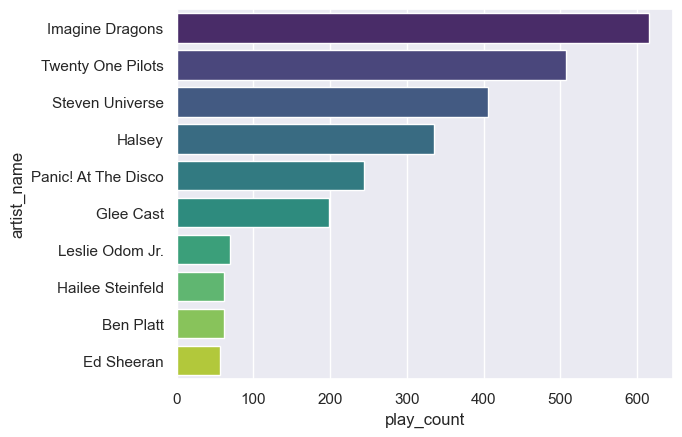

In [15]:
# print a bar plot including the top 10 artists of 2017
sns.barplot(x="play_count", y="artist_name", data=top_artists_2017,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 10 artists of 2017
top_artists_2017_anagram = top_artists_2017.melt(id_vars=["artist_name"], value_name="play count").drop(columns=["variable"])
top_artists_2017_anagram.head(10)

### Top 5 Albums

,album_name,play_count,artist name
0,"Steven Universe, Vol. 1 (Original Soundtrack)",406,Steven Universe
1,Evolve,204,Imagine Dragons
2,Night Visions,202,Imagine Dragons
3,Smoke + Mirrors,196,Imagine Dragons
4,hopeless fountain kingdom,178,Halsey


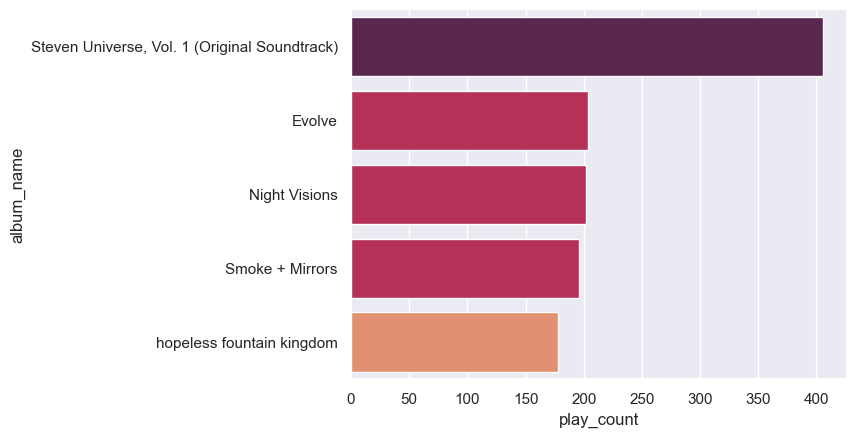

In [16]:
# print a bar plot including the top 5 albums of 2017
sns.barplot(x="play_count", y="album_name", data=top_albums_2017,
            label="Total", palette="rocket", hue="artist_name", legend=False)
# print a table including the top 5 albums of 2017
top_albums_2017_anagram = top_albums_2017.melt(id_vars=["album_name", "play_count"], value_name="artist name").drop(columns=["variable"])
top_albums_2017_anagram.head(5)

## 2018

In [17]:
print(
    "==================================================================================\n"
    "In 2018, you've enjoyed music for a total of", minutes_2018, "minutes, or", hours_2018, "hours, or ", days_2018, "days \n"
    "=================================================================================="
)

In 2018, you've enjoyed music for a total of 19912 minutes, or 331 hours, or  13 days 


### Top 10 Songs

,song_title,album_name,play_count,artist
0,Da Ya Think I'm Sexy,Da Ya Think I'm Sexy?,43,Rod Stewart
1,Panic Room,Panic Room,41,Au/Ra
2,Never Enough,The Greatest Showman (Original Motion Picture ...,40,Loren Allred
3,Everybody Wants To Rule The World,Songs From The Big Chair,37,Tears For Fears
4,"Golden Slumbers / Carry That Weight - From ""Si...",Sing - Original Motion Picture Soundtrack / De...,36,Jennifer Hudson
5,The Love Club,Pure Heroine,33,Lorde
6,Old Fashioned,Pray for the Wicked,32,Panic! At The Disco
7,This Is Me,The Greatest Showman (Original Motion Picture ...,32,Keala Settle
8,Monkey Tree - UK Mix,Very Good Bad Thing,31,Mother Mother
9,War!,War!,30,Zach Callison


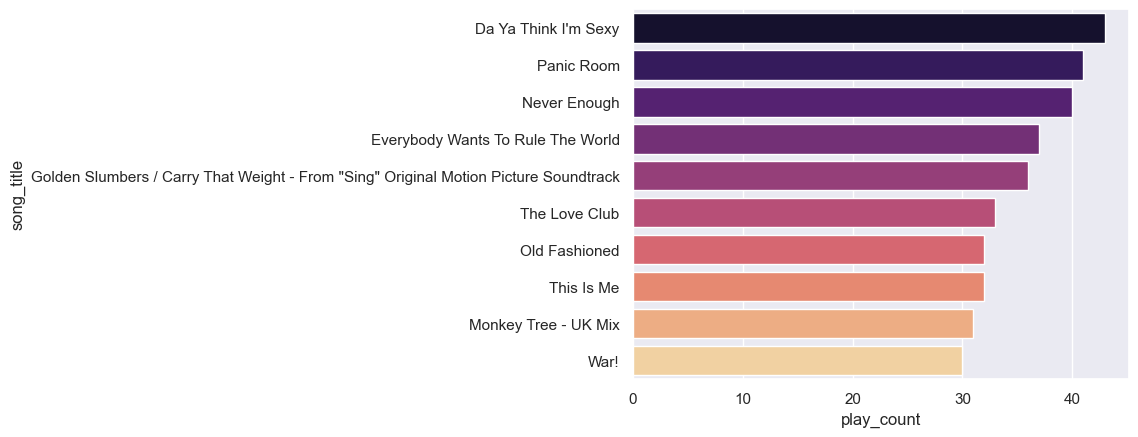

In [18]:
# print a bar plot including the top 10 tracks of 2018
sns.barplot(x="play_count", y="song_title", data=top_tracks_2018,
            label="Total", palette="magma", hue="song_title", legend=False)
# print a table including the top 10 tracks of 2018
top_tracks_2018_anagram = top_tracks_2018.melt(id_vars=["song_title", "album_name", "play_count"], value_name="artist").drop(columns=["variable"])
top_tracks_2018_anagram.head(10)

### Top 10 Artists

,artist_name,play count
0,Panic! At The Disco,386
1,Twenty One Pilots,381
2,Lorde,348
3,Imagine Dragons,236
4,Original Broadway Cast of Hamilton,232
5,Steven Universe,203
6,John Powell,149
7,Halsey,128
8,Zach Callison,116
9,Lin-Manuel Miranda,113


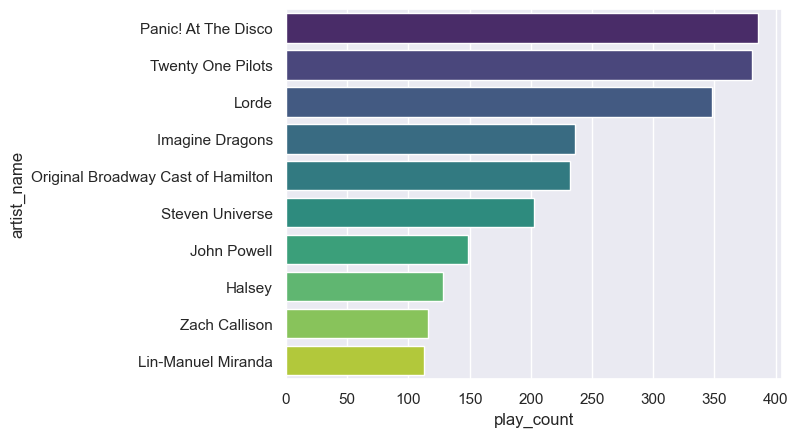

In [19]:
# print a bar plot including the top 10 artists of 2018
sns.barplot(x="play_count", y="artist_name", data=top_artists_2018,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 10 artists of 2018
top_artists_2018_anagram = top_artists_2018.melt(id_vars=["artist_name"], value_name="play count").drop(columns=["variable"])
top_artists_2018_anagram.head(10)

### Top 5 Albums

,album_name,play_count,artist name
0,Pure Heroine,248,Lorde
1,Pray for the Wicked,224,Panic! At The Disco
2,"Steven Universe, Vol. 1 (Original Soundtrack)",187,Steven Universe
3,The Hamilton Instrumentals,163,Original Broadway Cast of Hamilton
4,How To Train Your Dragon - Music From The Moti...,149,John Powell


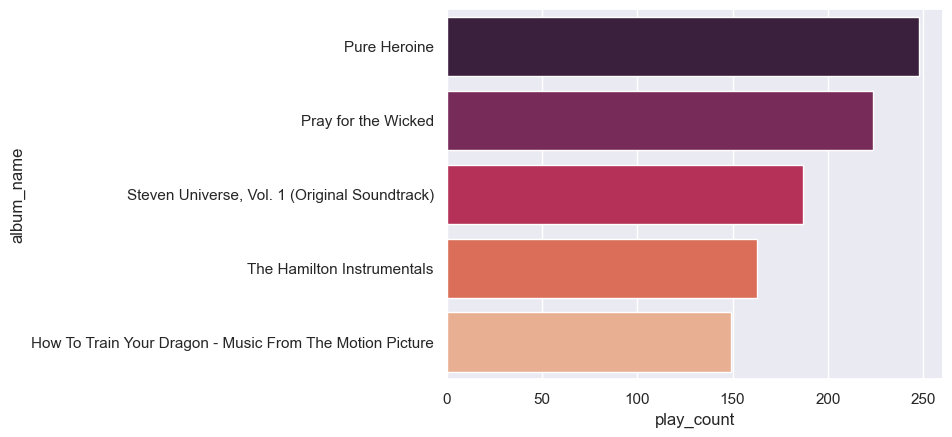

In [20]:
# print a bar plot including the top 5 albums of 2018
sns.barplot(x="play_count", y="album_name", data=top_albums_2018,
            label="Total", palette="rocket", hue="artist_name", legend=False)
# print a table including the top 5 albums of 2018
top_albums_2018_anagram = top_albums_2018.melt(id_vars=["album_name", "play_count"], value_name="artist name").drop(columns=["variable"])
top_albums_2018_anagram.head(5)

## 2019

In [21]:
print(
    "==================================================================================\n"
    "In 2019, you've enjoyed music for a total of", minutes_2019, "minutes, or", hours_2019, "hours, or ", days_2019, "days \n"
    "=================================================================================="
)

In 2019, you've enjoyed music for a total of 21357 minutes, or 355 hours, or  14 days 


### Top 10 Songs

,song_title,album_name,play_count,artist
0,Kissaphobic,Visions of Hollywood,37,Make Out Monday
1,Private Fears in Public Places,Aware,37,Front Porch Step
2,Promise Me,A Good Friend Is Nice,34,Jack & Jack
3,Lethal Combination,Beautiful People Will Ruin Your Life,34,The Wombats
4,The Only Hope for Me Is You,Danger Days: The True Lives of the Fabulous Ki...,33,My Chemical Romance
5,Monkey Tree - UK Mix,Very Good Bad Thing,32,Mother Mother
6,Girls Like Girls,This Side of Paradise,31,Hayley Kiyoko
7,And There You Are,And There You Are,31,Alex Walker Smith
8,Freaks,Freaks,31,Jordan Clarke
9,Dusk Till Dawn (feat. Sia) - Radio Edit,Dusk Till Dawn (feat. Sia),30,ZAYN


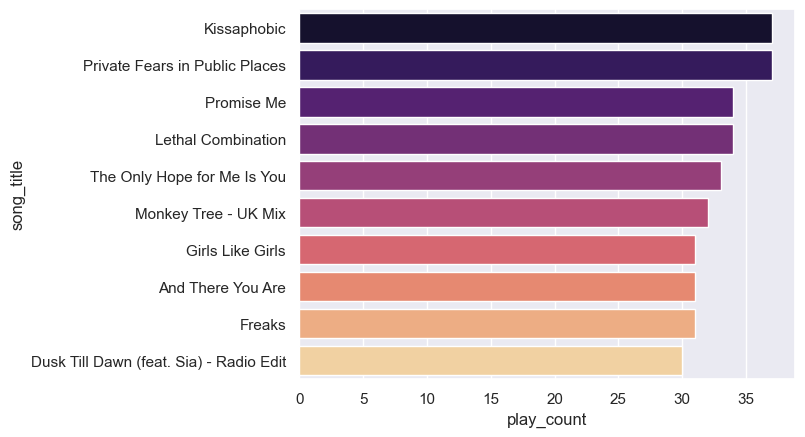

In [22]:
# print a bar plot including the top 10 tracks of 2019
sns.barplot(x="play_count", y="song_title", data=top_tracks_2019,
            label="Total", palette="magma", hue="song_title", legend=False)
# print a table including the top 10 tracks of 2019
top_tracks_2019_anagram = top_tracks_2019.melt(id_vars=["song_title", "album_name", "play_count"], value_name="artist").drop(columns=["variable"])
top_tracks_2019_anagram.head(10)

### Top 10 Artists

,artist_name,play count
0,One Direction,636
1,Bleachers,235
2,YUNGBLUD,197
3,Twenty One Pilots,172
4,Jack & Jack,134
5,My Chemical Romance,125
6,Steven Universe,124
7,Lorde,112
8,Panic! At The Disco,109
9,Billie Eilish,97


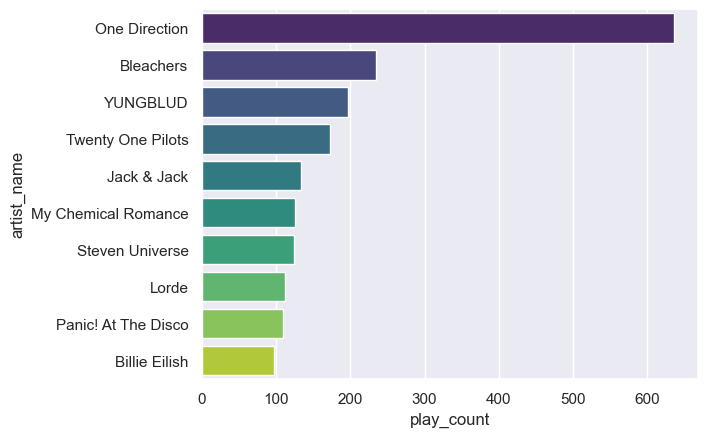

In [23]:
# print a bar plot including the top 10 artists of 2019
sns.barplot(x="play_count", y="artist_name", data=top_artists_2019,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 10 artists of 2019
top_artists_2019_anagram = top_artists_2019.melt(id_vars=["artist_name"], value_name="play count").drop(columns=["variable"])
top_artists_2019_anagram.head(10)

### Top 5 Albums

,album_name,play_count,artist name
0,21st Century Liability,194,YUNGBLUD
1,Midnight Memories (Deluxe),183,One Direction
2,Up All Night,178,One Direction
3,Take Me Home: Yearbook Edition,147,One Direction
4,A Good Friend Is Nice,133,Jack & Jack


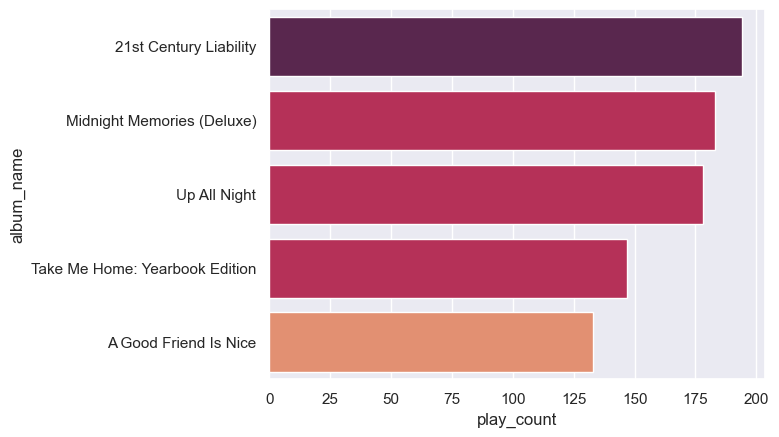

In [24]:
# print a bar plot including the top 5 Albums of 2019
sns.barplot(x="play_count", y="album_name", data=top_albums_2019,
            label="Total", palette="rocket", hue="artist_name", legend=False)
# print a table including the top 5 Albums of 2019
top_albums_2019_anagram = top_albums_2019.melt(id_vars=["album_name", "play_count"], value_name="artist name").drop(columns=["variable"])
top_albums_2019_anagram.head(5)

## 2020

In [25]:
print(
    "==================================================================================\n"
    "In 2020, you've enjoyed music for a total of", minutes_2020, "minutes, or", hours_2020, "hours, or ", days_2020, "days \n"
    "=================================================================================="
)

In 2020, you've enjoyed music for a total of 21057 minutes, or 350 hours, or  14 days 


### Top 10 Songs

,song_title,album_name,play_count,artist
0,Therapy,An Invitation to an Alternate Reality,47,New Politics
1,Human,Day & Age - Bonus Tracks,46,The Killers
2,Breakup Haircut,Breakup Haircut,44,Danny and Alex
3,Sisters,The Original Motion Picture Soundtrack: Pt. 1,43,Saint Motel
4,Starlight,Black Holes and Revelations,42,Muse
5,Goodbye Copenhagen,A Bad Girl In Harlem,40,New Politics
6,Girl Crush,Vikings,40,New Politics
7,United States of Eurasia (+Collateral Damage),The Resistance,40,Muse
8,Cold Cold Man,My Type EP,38,Saint Motel
9,Cemetery,Dreamland,37,COIN


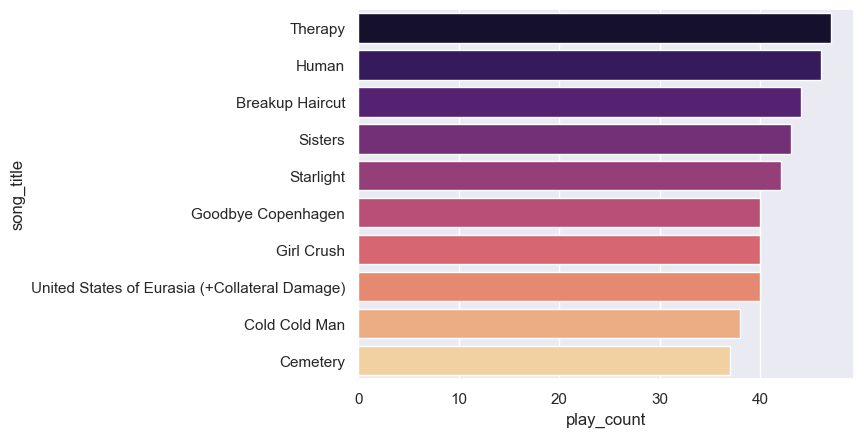

In [26]:
# print a bar plot including the top 10 tracks of 2020
sns.barplot(x="play_count", y="song_title", data=top_tracks_2020,
            label="Total", palette="magma", hue="song_title", legend=False)
# print a table including the top 10 tracks of 2020
top_tracks_2020_anagram = top_tracks_2020.melt(id_vars=["song_title", "album_name", "play_count"], value_name="artist").drop(columns=["variable"])
top_tracks_2020_anagram.head(10)

### Top 10 Artists

,artist_name,play count
0,Muse,551
1,One Direction,327
2,Blue October,315
3,New Politics,256
4,Bleachers,227
5,COIN,141
6,Saint Motel,121
7,My Chemical Romance,104
8,Chapel,101
9,YUNGBLUD,97


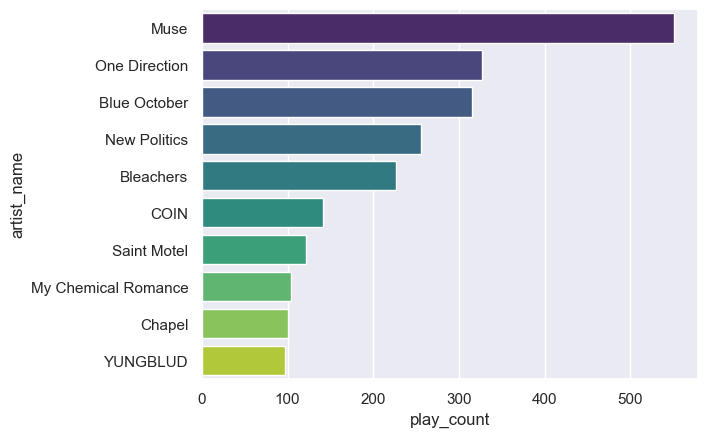

In [27]:
# print a bar plot including the top 10 artists of 2020
sns.barplot(x="play_count", y="artist_name", data=top_artists_2020,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 10 artists of 2020
top_artists_2020_anagram = top_artists_2020.melt(id_vars=["artist_name"], value_name="play count").drop(columns=["variable"])
top_artists_2020_anagram.head(10)

### Top 5 Albums

,album_name,play_count,artist name
0,Black Holes and Revelations,207,Muse
1,The Resistance,170,Muse
2,I Hope You're Happy,114,Blue October
3,Simulation Theory,110,Muse
4,Strange Desire,108,Bleachers


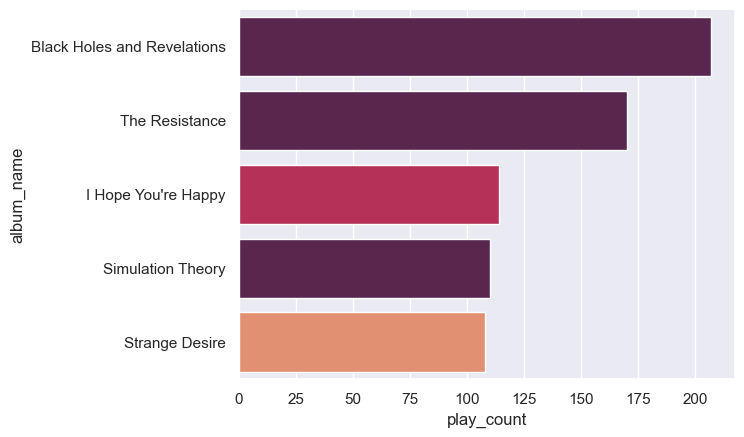

In [28]:
# print a bar plot including the top 5 Albums of 2020
sns.barplot(x="play_count", y="album_name", data=top_albums_2020,
            label="Total", palette="rocket", hue="artist_name", legend=False)
# print a table including the top 5 Albums of 2020
top_albums_2020_anagram = top_albums_2020.melt(id_vars=["album_name", "play_count"], value_name="artist name").drop(columns=["variable"])
top_albums_2020_anagram.head(5)

## 2021

In [29]:
print(
    "==================================================================================\n"
    "In 2021, you've enjoyed music for a total of", minutes_2021, "minutes, or", hours_2021, "hours, or ", days_2021, "days \n"
    "=================================================================================="
)

In 2021, you've enjoyed music for a total of 21873 minutes, or 364 hours, or  15 days 


### Top 10 Songs

,song_title,album_name,play_count,artist
0,Bullet for Your Sweetheart,Visions of Hollywood,42,Make Out Monday
1,Potential Breakup Song,Potential Breakup Song,37,Aly & AJ
2,Revolt,Drones,37,Muse
3,Bulletproof Heart,Danger Days: The True Lives of the Fabulous Ki...,35,My Chemical Romance
4,On Melancholy Hill,Plastic Beach,34,Gorillaz
5,Creep,Pablo Honey,34,Radiohead
6,Uprising,The Resistance,33,Muse
7,Disenchanted,The Black Parade,33,My Chemical Romance
8,Reapers,Drones,33,Muse
9,The Night We Met,Strange Trails,32,Lord Huron


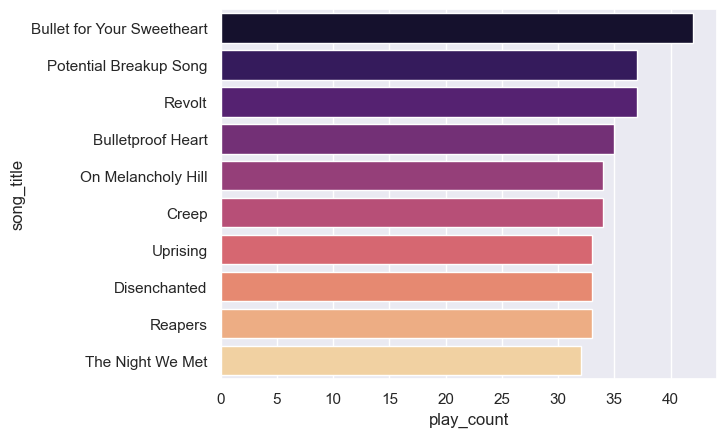

In [30]:
# print a bar plot including the top 10 tracks of 2021
sns.barplot(x="play_count", y="song_title", data=top_tracks_2021,
            label="Total", palette="magma", hue="song_title", legend=False)
# print a table including the top 10 tracks of 2021
top_tracks_2021_anagram = top_tracks_2021.melt(id_vars=["song_title", "album_name", "play_count"], value_name="artist").drop(columns=["variable"])
top_tracks_2021_anagram.head(10)

### Top 10 Artists

,artist_name,play count
0,My Chemical Romance,447
1,Muse,446
2,One Direction,225
3,Mother Mother,142
4,Neon Trees,140
5,Blue October,139
6,Bleachers,122
7,ConcernedApe,105
8,Lorde,96
9,Rise Against,95


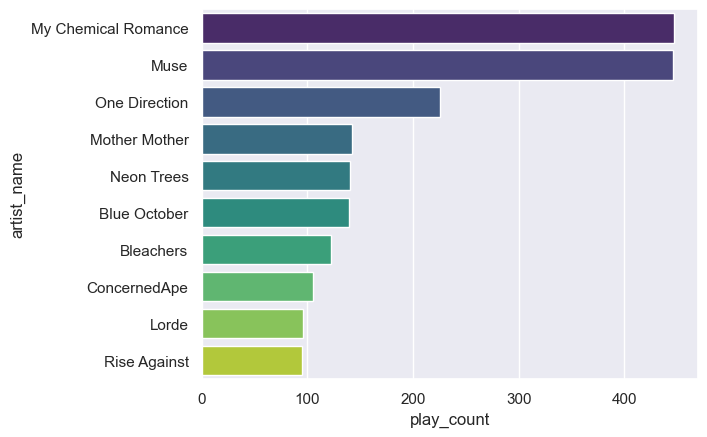

In [31]:
# print a bar plot including the top 10 artists of 2021
sns.barplot(x="play_count", y="artist_name", data=top_artists_2021,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 10 artists of 2021
top_artists_2021_anagram = top_artists_2021.melt(id_vars=["artist_name"], value_name="play count").drop(columns=["variable"])
top_artists_2021_anagram.head(10)

### Top 5 Albums

,album_name,play_count,artist name
0,The Black Parade,188,My Chemical Romance
1,Drones,149,Muse
2,Danger Days: The True Lives of the Fabulous Ki...,138,My Chemical Romance
3,The Resistance,109,Muse
4,Stardew Valley (Original Game Soundtrack),93,ConcernedApe


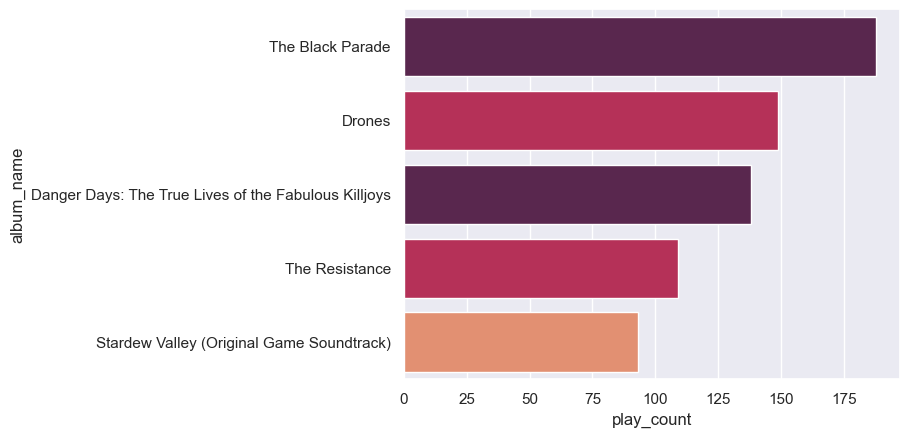

In [32]:
# print a bar plot including the top 5 Albums of 2021
sns.barplot(x="play_count", y="album_name", data=top_albums_2021,
            label="Total", palette="rocket", hue="artist_name", legend=False)
# print a table including the top 5 Albums of 2021
top_albums_2021_anagram = top_albums_2021.melt(id_vars=["album_name", "play_count"], value_name="artist name").drop(columns=["variable"])
top_albums_2021_anagram.head(5)

## 2022

In [33]:
print(
    "==================================================================================\n"
    "In 2022, you've enjoyed music for a total of", minutes_2022, "minutes, or", hours_2022, "hours, or ", days_2022, "days \n"
    "=================================================================================="
)

In 2022, you've enjoyed music for a total of 27367 minutes, or 456 hours, or  19 days 


### Top 10 Songs

,song_title,album_name,play_count,artist
0,Call Me Little Sunshine,IMPERA,45,Ghost
1,Pressure,Simulation Theory,42,Muse
2,Pleasure,Feels Like We’ve Been Here Before,40,Betcha
3,Jenny Was A Friend Of Mine,Hot Fuss,39,The Killers
4,Revolt,Drones,38,Muse
5,Houdini,Torches,37,Foster The People
6,You Make Me Feel Like It’s Halloween,Will Of The People,35,Muse
7,Deus In Absentia,Meliora,33,Ghost
8,Neon Tiger,Day & Age - Bonus Tracks,33,The Killers
9,Swim Naked,Falling,33,Betcha


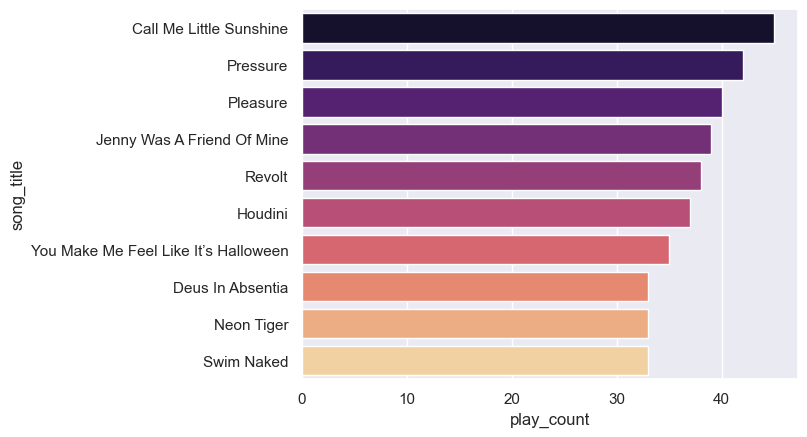

In [34]:
# print a bar plot including the top 10 tracks of 2022
sns.barplot(x="play_count", y="song_title", data=top_tracks_2022,
            label="Total", palette="magma", hue="song_title", legend=False)
# print a table including the top 10 tracks of 2022
top_tracks_2022_anagram = top_tracks_2022.melt(id_vars=["song_title", "album_name", "play_count"], value_name="artist").drop(columns=["variable"])
top_tracks_2022_anagram.head(10)

### Top 10 Artists

,artist_name,play count
0,Muse,798
1,Ghost,426
2,One Direction,274
3,My Chemical Romance,264
4,flipturn,224
5,The Killers,181
6,Mother Mother,171
7,Betcha,163
8,Bleachers,136
9,Blue October,129


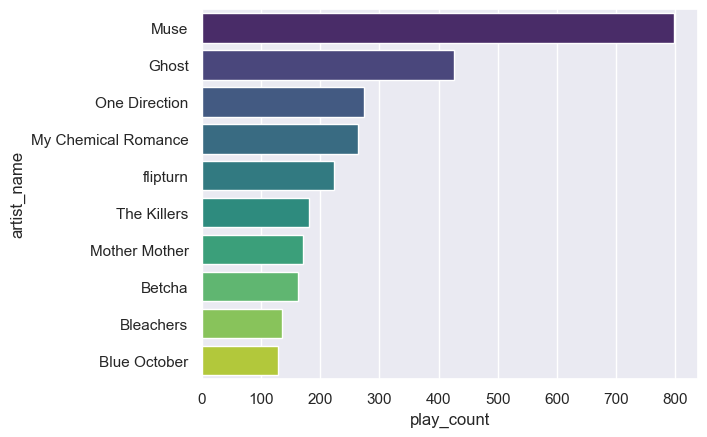

In [35]:
# print a bar plot including the top 10 artists of 2022
sns.barplot(x="play_count", y="artist_name", data=top_artists_2022,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 10 artists of 2022
top_artists_2022_anagram = top_artists_2022.melt(id_vars=["artist_name"], value_name="play count").drop(columns=["variable"])
top_artists_2022_anagram.head(10)

### Top 5 Albums

,album_name,play_count,artist name
0,IMPERA,151,Ghost
1,Will Of The People,145,Muse
2,Absolution,133,Muse
3,Drones,123,Muse
4,Meliora,117,Ghost


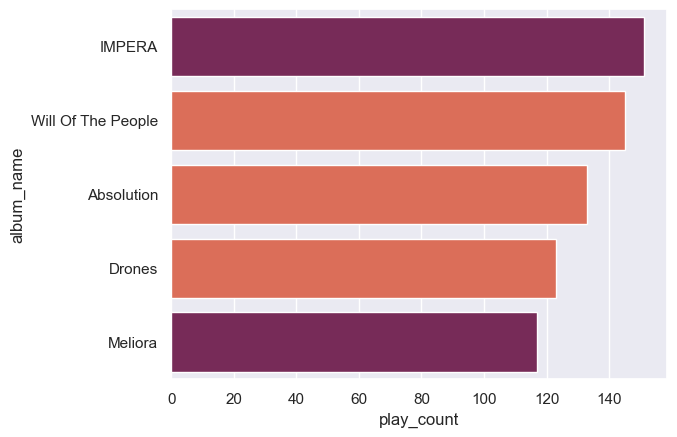

In [36]:
# print a bar plot including the top 5 Albums of 2022
sns.barplot(x="play_count", y="album_name", data=top_albums_2022,
            label="Total", palette="rocket", hue="artist_name", legend=False)
# print a table including the top 5 Albums of 2022
top_albums_2022_anagram = top_albums_2022.melt(id_vars=["album_name", "play_count"], value_name="artist name").drop(columns=["variable"])
top_albums_2022_anagram.head(5)

## 2023

In [37]:
print(
    "==================================================================================\n"
    "In 2023, you've enjoyed music for a total of", minutes_2023, "minutes, or", hours_2023, "hours, or ", days_2023, "days \n"
    "=================================================================================="
)

In 2023, you've enjoyed music for a total of 16882 minutes, or 281 hours, or  11 days 


### Top 10 Songs

,song_title,album_name,play_count,artist
0,Thunderstruck,The Razors Edge,46,AC/DC
1,Enjoy the Silence - 2006 Remaster,Violator,43,Depeche Mode
2,Darkness At The Heart Of My Love,IMPERA,42,Ghost
3,Plug in Baby,Origin of Symmetry,35,Muse
4,Faith,Prequelle,33,Ghost
5,Cliffs Of Dover - Instrumental,Ah Via Musicom,30,Eric Johnson
6,Cirice,Meliora,30,Ghost
7,My Girlfriend's Girlfriend,October Rust,29,Type O Negative
8,You Shook Me All Night Long,Back In Black,29,AC/DC
9,1983,Habits,27,Neon Trees


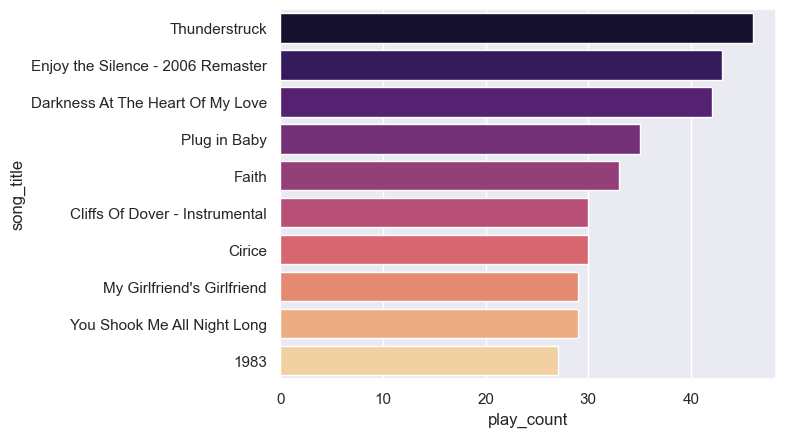

In [38]:
# print a bar plot including the top 10 tracks of 2023
sns.barplot(x="play_count", y="song_title", data=top_tracks_2023,
            label="Total", palette="magma", hue="song_title", legend=False)
# print a table including the top 10 tracks of 2023
top_tracks_2023_anagram = top_tracks_2023.melt(id_vars=["song_title", "album_name", "play_count"], value_name="artist").drop(columns=["variable"])
top_tracks_2023_anagram.head(10)

### Top 10 Artists

,artist_name,play count
0,Ghost,434
1,Muse,428
2,Neon Trees,180
3,The Killers,133
4,My Chemical Romance,110
5,Type O Negative,105
6,Mitski,99
7,Nuovo Testamento,88
8,AC/DC,87
9,Bleachers,83


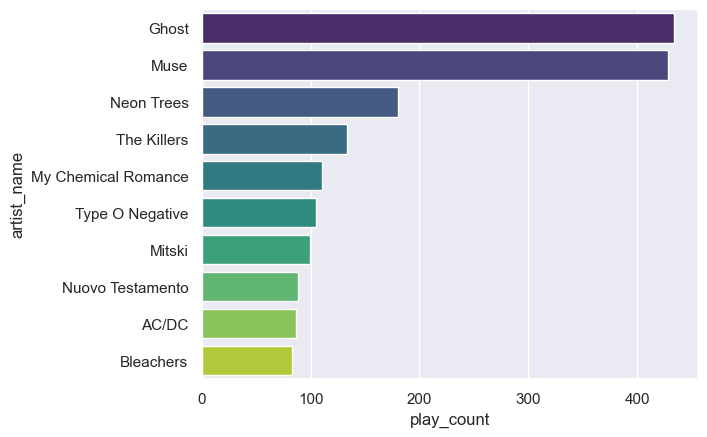

In [39]:
# print a bar plot including the top 10 artists of 2023
sns.barplot(x="play_count", y="artist_name", data=top_artists_2023,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 10 artists of 2023
top_artists_2023_anagram = top_artists_2023.melt(id_vars=["artist_name"], value_name="play count").drop(columns=["variable"])
top_artists_2023_anagram.head(10)

### Top 5 Albums

,album_name,play_count,artist name
0,IMPERA,116,Ghost
1,Meliora,97,Ghost
2,Prequelle,97,Ghost
3,Will Of The People,91,Muse
4,October Rust,82,Type O Negative


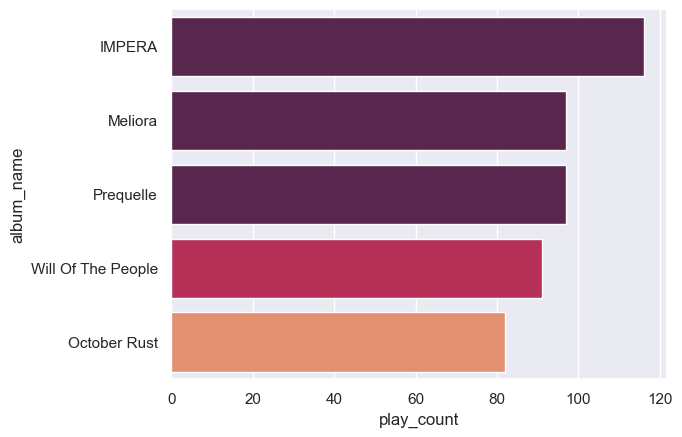

In [40]:
# print a bar plot including the top 5 Albums of 2023
sns.barplot(x="play_count", y="album_name", data=top_albums_2023,
            label="Total", palette="rocket", hue="artist_name", legend=False)
# print a table including the top 5 Albums of 2023
top_albums_2023_anagram = top_albums_2023.melt(id_vars=["album_name", "play_count"], value_name="artist name").drop(columns=["variable"])
top_albums_2023_anagram.head(5)

## 2024

In [41]:
print(
    "==================================================================================\n"
    "In 2024, you've enjoyed music for a total of", minutes_2024, "minutes, or", hours_2024, "hours, or ", days_2024, "days \n"
    "=================================================================================="
)

In 2024, you've enjoyed music for a total of 21031 minutes, or 350 hours, or  14 days 


### Top 10 Songs

,song_title,album_name,play_count,artist
0,Silver,Wonderland,45,Nosferatu
1,Red Wine Supernova,The Rise and Fall of a Midwest Princess,43,Chappell Roan
2,Lucretia My Reflection - Vinyl Version,Floodland,33,Sisters of Mercy
3,Black Planet,First and Last and Always,33,Sisters of Mercy
4,Pink Pony Club,The Rise and Fall of a Midwest Princess,32,Chappell Roan
5,Lullaby,Greatest Hits,32,The Cure
6,Here Comes Your Man,Doolittle,31,Pixies
7,Toxicity,Toxicity,31,System Of A Down
8,All I Need,In Rainbows,31,Radiohead
9,Boys Don't Cry - Single Version,Three Imaginary Boys,30,The Cure


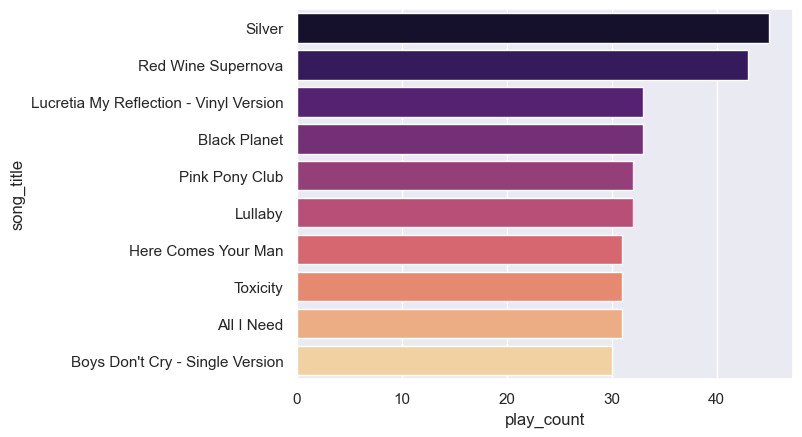

In [42]:
# print a bar plot including the top 10 tracks of 2024
sns.barplot(x="play_count", y="song_title", data=top_tracks_2024,
            label="Total", palette="magma", hue="song_title", legend=False)
# print a table including the top 10 tracks of 2024
top_tracks_2024_anagram = top_tracks_2024.melt(id_vars=["song_title", "album_name", "play_count"], value_name="artist").drop(columns=["variable"])
top_tracks_2024_anagram.head(10)

### Top 10 Artists

,artist_name,play count
0,Muse,406
1,Chappell Roan,304
2,Ghost,283
3,One Direction,210
4,The Cure,117
5,My Chemical Romance,113
6,Neon Trees,111
7,The Killers,109
8,Mitski,106
9,Nuovo Testamento,104


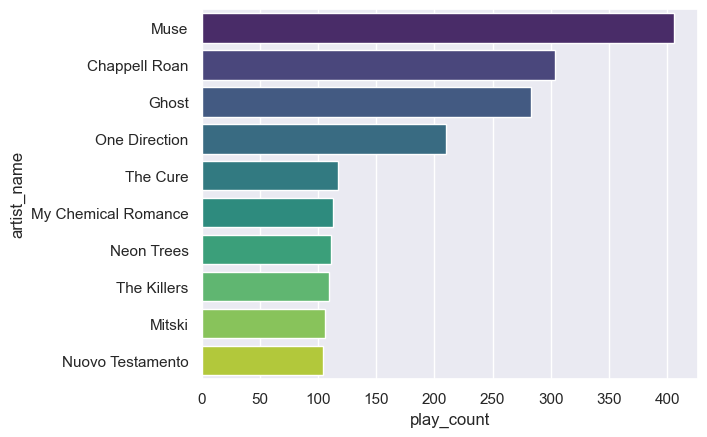

In [43]:
# print a bar plot including the top 10 artists of 2024
sns.barplot(x="play_count", y="artist_name", data=top_artists_2024,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 10 artists of 2024
top_artists_2024_anagram = top_artists_2024.melt(id_vars=["artist_name"], value_name="play count").drop(columns=["variable"])
top_artists_2024_anagram.head(10)

### Top 5 Albums

,album_name,play_count,artist name
0,The Rise and Fall of a Midwest Princess,241,Chappell Roan
1,Tonight The Stars Revolt,78,Powerman 5000
2,Black Holes and Revelations,64,Muse
3,The Resistance,64,Muse
4,Prelude to Ecstasy,63,The Last Dinner Party


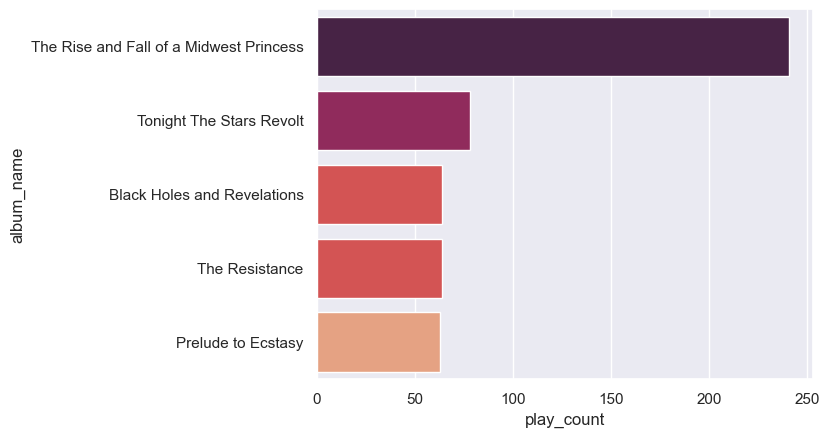

In [44]:
# print a bar plot including the top 5 Albums of 2024
sns.barplot(x="play_count", y="album_name", data=top_albums_2024,
            label="Total", palette="rocket", hue="artist_name", legend=False)
# print a table including the top 5 Albums of 2024
top_albums_2024_anagram = top_albums_2024.melt(id_vars=["album_name", "play_count"], value_name="artist name").drop(columns=["variable"])
top_albums_2024_anagram.head(5)

## 2025

In [45]:
print(
    "==================================================================================\n"
    "In 2025, you've enjoyed music for a total of", minutes_2025, "minutes, or", hours_2025, "hours, or ", days_2025, "days \n"
    "=================================================================================="
)

In 2025, you've enjoyed music for a total of 15827 minutes, or 263 hours, or  10 days 


### Top 10 Songs

,song_title,album_name,play_count,artist
0,Pumping Iron,Starlight Express,29,Andrew Lloyd Webber
1,Rolling Stock,Starlight Express,24,Andrew Lloyd Webber
2,Vanish Into You,MAYHEM,24,Lady Gaga
3,Perfect Celebrity,MAYHEM,23,Lady Gaga
4,Umbra,Skeletá,21,Ghost
5,Zombieboy,MAYHEM,21,Lady Gaga
6,Marks Of The Evil One,Skeletá,21,Ghost
7,Money For Nothing (Single Edit) - 2022 Remaster,Money For Nothing (2022 Remaster),20,Dire Straits
8,Crimson and Clover,I Love Rock 'N' Roll (Expanded Edition),20,Joan Jett & the Blackhearts
9,Cenotaph,Skeletá,20,Ghost


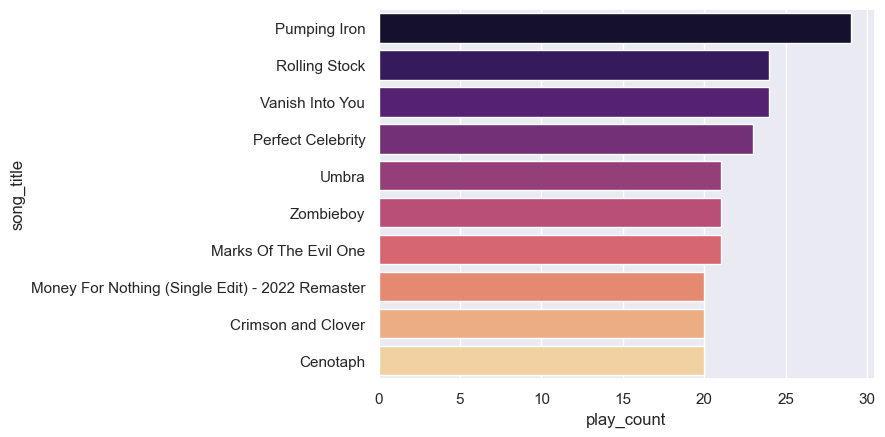

In [46]:
# print a bar plot including the top 10 tracks of 2025
sns.barplot(x="play_count", y="song_title", data=top_tracks_2025,
            label="Total", palette="magma", hue="song_title", legend=False)
# print a table including the top 10 tracks of 2025
top_tracks_2025_anagram = top_tracks_2025.melt(id_vars=["song_title", "album_name", "play_count"], value_name="artist").drop(columns=["variable"])
top_tracks_2025_anagram.head(10)

### Top 10 Artists

,artist_name,play count
0,Muse,344
1,Ghost,222
2,My Chemical Romance,188
3,Lady Gaga,144
4,Chappell Roan,129
5,Radiohead,84
6,Toby Fox,79
7,Paramore,65
8,Weezer,64
9,The Killers,60


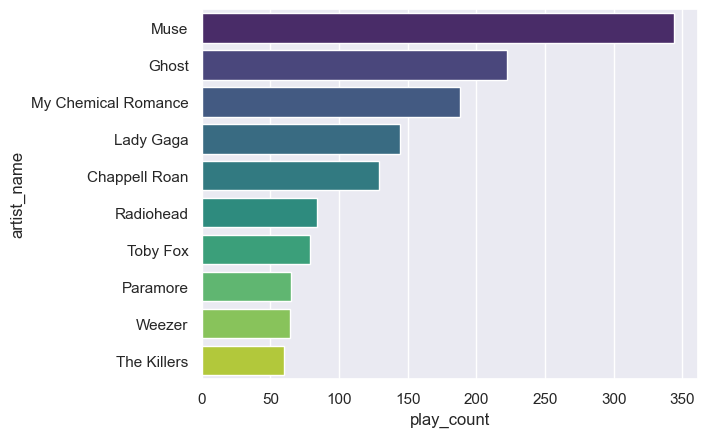

In [47]:
# print a bar plot including the top 10 artists of 2025
sns.barplot(x="play_count", y="artist_name", data=top_artists_2025,
            label="Total", palette="viridis", hue="artist_name", legend=False)
# print a table including the top 10 artists of 2025
top_artists_2025_anagram = top_artists_2025.melt(id_vars=["artist_name"], value_name="play count").drop(columns=["variable"])
top_artists_2025_anagram.head(10)

### Top 5 Albums

,album_name,play_count,artist name
0,MAYHEM,100,Lady Gaga
1,The Rise and Fall of a Midwest Princess,90,Chappell Roan
2,Drones,84,Muse
3,Danger Days: The True Lives of the Fabulous Ki...,74,My Chemical Romance
4,Skeletá,74,Ghost


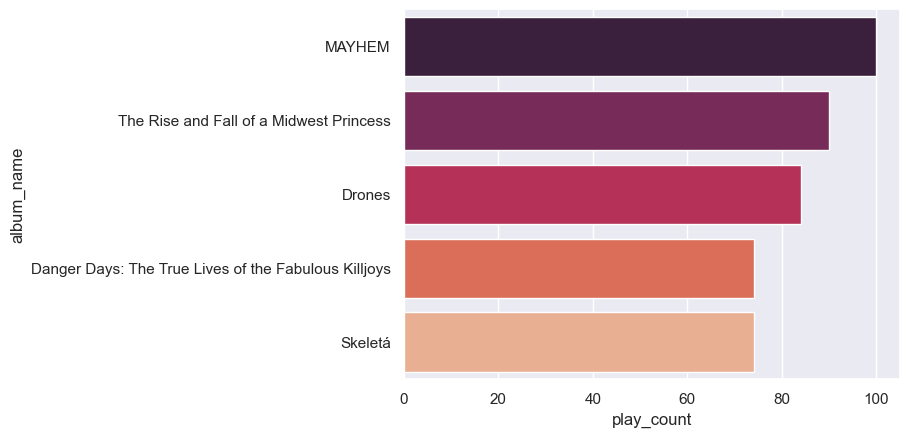

In [48]:
# print a bar plot including the top 5 Albums of 2025
sns.barplot(x="play_count", y="album_name", data=top_albums_2025,
            label="Total", palette="rocket", hue="artist_name", legend=False)
# print a table including the top 5 Albums of 2025
top_albums_2025_anagram = top_albums_2025.melt(id_vars=["album_name", "play_count"], value_name="artist name").drop(columns=["variable"])
top_albums_2025_anagram.head(5)